In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from tqdm import tqdm

from util import K_with_prior, perform_projection

Matplotlib is building the font cache; this may take a moment.


In [3]:
def plot_df_with_error(df, file_name, std_list_min_max, std_list_hisham, d_f, x_axis,  save_dir = 'plots', x_axis_name='Privacy Parameter $\\varepsilon$', save_fig=False):
    fig, ax = plt.subplots()

    # Plot each row with shaded areas for standard deviation
    row_names = df.index
    for i, row_label in enumerate(row_names):
        ax.plot(x_axis, df.loc[row_label], label=row_label, alpha=0.7)

        # Shade the area around each line plot
        ax.fill_between(x_axis,
                        df.loc[row_label] - std_list_min_max if i == 0 else df.loc[row_label] - std_list_hisham,
                        df.loc[row_label] + std_list_min_max if i == 0 else df.loc[row_label] + std_list_hisham,
                        alpha=0.2)

    # Set x-axis ticks to ensure they match the specified values
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    # Set labels and legend
    ax.set_xlabel(x_axis_name, fontsize=16)
    if d_f == 'tv':
        ax.set_ylabel('TV-Distance', fontsize=16)
    elif d_f == 'kl':
        ax.set_ylabel('KL-Divergence', fontsize=16)

    # Rotate x-axis labels for better visibility
    plt.xticks(rotation=45, ha='right')

    # Ensure all x-axis labels are shown and formatted
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax.legend()

    if save_fig:
        # Create directory if it does not exist
        os.makedirs(save_dir, exist_ok=True)
        
        # Full path for the file
        save_path = os.path.join(save_dir, file_name)
        
        # Save the figure
        plt.savefig(save_path, bbox_inches='tight', dpi=150)

    # Show plot
    plt.show()


In [4]:


def experiment_varying_p(n=100, n_sigma=10, eps=8, f_div='kl'):
    # Generate dirac values and corresponding minimum values
    dirac_value_list = np.linspace(1/n, 0.99, 100)
    min_value_list = (1 - dirac_value_list) / (n - 1)

    # Initialize DataFrame
    row_names = ['Our Approach', 'RM Framework']
    columns = [str(v) for v in dirac_value_list]
    df = pd.DataFrame(index=row_names, columns=columns).fillna(0.0)

    # Initialize values array for storing results
    shape = (2, len(dirac_value_list), n_sigma)
    Df_values = np.zeros(shape)

    # Iterate over n_sigma samples
    for i in tqdm(range(n_sigma)):
        np.random.seed(42 + i)
        q = np.random.uniform(size=n)
        q = q / np.sum(q)
        sorted_indices = np.argsort(q)
        q = q[sorted_indices]
        K = K_with_prior(q, eps)

        for j, dirac_value in enumerate(dirac_value_list):
            np.random.seed(42 + i + j)
            p = np.zeros(n)
            p[1:] = min_value_list[j]
            p[0] = dirac_value
            p = p[sorted_indices]

            min_max, hisham = perform_projection(p, q, eps, K, f_div)

            Df_values[0, j, i] = max(Df_values[0, j, i], min_max)
            Df_values[1, j, i] = max(Df_values[1, j, i], hisham)

    # Calculate mean values for DataFrame
    for i, v in enumerate(dirac_value_list):
        df.loc['Our Approach', str(v)] = np.mean(Df_values[0, i, :])
        df.loc['RM Framework', str(v)] = np.mean(Df_values[1, i, :])

    # Compute standard deviations
    std_list_min_max = [np.std(Df_values[0, i, :]) / np.sqrt(n_sigma) for i in range(len(dirac_value_list))]
    std_list_hisham = [np.std(Df_values[1, i, :]) / np.sqrt(n_sigma) for i in range(len(dirac_value_list))]

    # Plot the results and save to file
    file_name = f'Experiment_p_varying_{f_div}_{eps}_{n}.png'
    plot_df_with_error(
        df=df,
        file_name=file_name,
        std_list_min_max=std_list_min_max,
        std_list_hisham=std_list_hisham,
        d_f=f_div,
        x_axis=dirac_value_list,
        x_axis_name='$p^{1}$',
        save_fig=True
    )

# Example usage



100%|██████████| 10/10 [00:00<00:00, 49.26it/s]


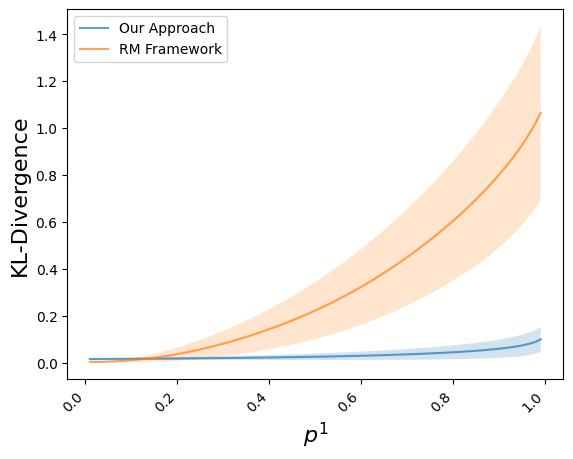

In [5]:
experiment_varying_p(f_div='kl')

  0%|          | 0/10 [00:00<?, ?it/s]

Restricted license - for non-production use only - expires 2026-11-23


100%|██████████| 10/10 [00:02<00:00,  3.74it/s]


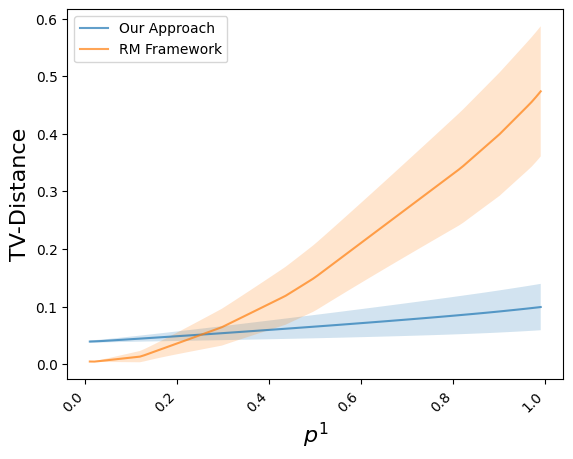

In [6]:
experiment_varying_p(f_div='tv')